In [1]:
import os
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Project paths
cwd = Path(os.getcwd())
project_root = cwd.parents[0]
data_root = project_root / 'data'

In [3]:
### Extract zip

'''
import zipfile

# extract zipfile
def extract_zip(file_name):
    zip_file_path = data_folder / 'raw' / file_name
    if zip_file_path.exists():
        out_fld = data_folder / 'interim' / Path(file_name).stem
        if not out_fld.exists():
            out_fld.mkdir(parents=True)
        with zipfile.ZipFile(zip_file_path, 'r') as zipref:
            zipref.extractall(out_fld)
        print(f"Extracted '{file_name}' to: {out_fld}")
        return out_fld
    else:
        print(f'file {file_name} is not present in the raw data folder. Could not open zip file')
        return None
'''

'\nimport zipfile\n\n# extract zipfile\ndef extract_zip(file_name):\n    zip_file_path = data_folder / \'raw\' / file_name\n    if zip_file_path.exists():\n        out_fld = data_folder / \'interim\' / Path(file_name).stem\n        if not out_fld.exists():\n            out_fld.mkdir(parents=True)\n        with zipfile.ZipFile(zip_file_path, \'r\') as zipref:\n            zipref.extractall(out_fld)\n        print(f"Extracted \'{file_name}\' to: {out_fld}")\n        return out_fld\n    else:\n        print(f\'file {file_name} is not present in the raw data folder. Could not open zip file\')\n        return None\n'

In [4]:
### Provide path to zipfile

# zip_filename = 'coffee_review_orig.zip'
# extracted_fld = extract_zip(zip_filename)

In [5]:
# path to data folder
data_fld = data_root / 'interim' / 'coffee_review_orig'

In [6]:
all_files = [file_path for file_path in data_fld.iterdir()]

In [7]:
all_files

[PosixPath('/home/shiska07/Projects/TheCoffeeEnthusiast/data/interim/coffee_review_orig/coffee_df.csv'),
 PosixPath('/home/shiska07/Projects/TheCoffeeEnthusiast/data/interim/coffee_review_orig/coffee_df_test.csv'),
 PosixPath('/home/shiska07/Projects/TheCoffeeEnthusiast/data/interim/coffee_review_orig/slug.csv'),
 PosixPath('/home/shiska07/Projects/TheCoffeeEnthusiast/data/interim/coffee_review_orig/slug1.csv'),
 PosixPath('/home/shiska07/Projects/TheCoffeeEnthusiast/data/interim/coffee_review_orig/coffee_df_with_type_and_region.csv'),
 PosixPath('/home/shiska07/Projects/TheCoffeeEnthusiast/data/interim/coffee_review_orig/coffee_fix.csv'),
 PosixPath('/home/shiska07/Projects/TheCoffeeEnthusiast/data/interim/coffee_review_orig/coffee_df_og.csv')]

In [8]:
dfs = dict()
for single_file in all_files:
    file_name = single_file.stem
    ext = single_file.suffix
    if ext in ['.csv']:
        df = pd.read_csv(single_file)
        dfs[file_name] = df

In [9]:
key_list = list(dfs.keys())
key_list

['coffee_df',
 'coffee_df_test',
 'slug',
 'slug1',
 'coffee_df_with_type_and_region',
 'coffee_fix',
 'coffee_df_og']

In [10]:
## using 'coffee_fix' as it is the data with the most complete info
df = dfs['coffee_fix'].copy()

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2282 entries, 0 to 2281
Data columns (total 20 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   slug         2282 non-null   str    
 1   all_text     2282 non-null   str    
 2   rating       2282 non-null   int64  
 3   roaster      2282 non-null   str    
 4   name         2282 non-null   str    
 5   location     2281 non-null   str    
 6   origin       2282 non-null   str    
 7   roast        2229 non-null   str    
 8   est_price    2277 non-null   str    
 9   review_date  2282 non-null   str    
 10  agtron       2282 non-null   str    
 11  aroma        2255 non-null   float64
 12  acid         1947 non-null   float64
 13  body         2279 non-null   float64
 14  flavor       2279 non-null   float64
 15  aftertaste   2279 non-null   float64
 16  with_milk    356 non-null    float64
 17  desc_1       2282 non-null   str    
 18  desc_2       2282 non-null   str    
 19  desc_3       2280

In [12]:
df.head()

,slug,all_text,rating,roaster,name,location,origin,roast,est_price,review_date,agtron,aroma,acid,body,flavor,aftertaste,with_milk,desc_1,desc_2,desc_3
0,https://www.coffeereview.com/review/sweety-esp...,\n\n\n95\n\n\nA.R.C.\n“Sweety” Espresso Blend...,95,A.R.C.,“Sweety” Espresso Blend,"Hong Kong, China",Panama; Ethiopia,Medium-Light,HKD $250/227 grams,November 2017,50/73,9.0,NaN,9.0,9.0,9.0,9.0,"Evaluated as espresso. Sweet-toned, deeply ric...",An espresso blend comprised of coffees from Pa...,A radiant espresso blend that shines equally i...
1,https://www.coffeereview.com/review/flora-blen...,\n\n\n94\n\n\nA.R.C.\nFlora Blend Espresso\n\...,94,A.R.C.,Flora Blend Espresso,"Hong Kong, China",Africa; Asia Pacific,Medium-Light,HKD $158/227 grams,November 2017,54/77,9.0,NaN,9.0,9.0,8.0,9.0,"Evaluated as espresso. Sweetly tart, floral-to...",An espresso blend comprised of coffees from Af...,"A floral-driven straight shot, amplified with ..."
2,https://www.coffeereview.com/review/ethiopia-s...,\n\n\n92\n\n\nRevel Coffee\nEthiopia Shakiso ...,92,Revel Coffee,Ethiopia Shakiso Mormora,"Billings, Montana","Guji Zone, southern Ethiopia",Medium-Light,$16.00/12 ounces,November 2017,54/70,9.0,8.0,8.0,9.0,8.0,NaN,"Crisply sweet, cocoa-toned. Lemon blossom, roa...",This coffee tied for the third-highest rating ...,"A gently spice-toned, floral- driven wet-proce..."
3,https://www.coffeereview.com/review/ethiopia-s...,\n\n\n92\n\n\nRoast House\nEthiopia Suke Quto...,92,Roast House,Ethiopia Suke Quto,"Spokane, Washington","Guji Zone, Oromia Region, south-central Ethiopia",Medium-Light,$19.00/16 ounces,November 2017,53/79,8.0,8.0,9.0,9.0,8.0,NaN,"Delicate, sweetly spice-toned. Pink peppercorn...",This coffee tied for the third-highest rating ...,Lavender-like flowers and hints of zesty pink ...
4,https://www.coffeereview.com/review/ethiopia-g...,\n\n\n94\n\n\nBig Creek Coffee Roasters\nEthi...,94,Big Creek Coffee Roasters,Ethiopia Gedeb Halo Beriti,"Hamilton, Montana","Gedeb District, Gedeo Zone, southern Ethiopia",Medium,$16.50/12 ounces,November 2017,48/70,9.0,9.0,9.0,9.0,8.0,NaN,"Deeply sweet, subtly pungent. Honey, pear, tan...",Southern Ethiopia coffees like this one are pr...,A deeply and generously lush cup saved from se...


### Data Cleaning

What we embed matters a lot for how well semantic search actually works — the goal is to keep the 
embedded text focused on content that's actually relevant. So before deciding on a final text field, I'm going through each candidate column 
(`all_text`, `desc_1`, `desc_2`, `desc_3`) and checking for anything that doesn't add value.

In [13]:
## View 'all_text' column
df['all_text'][2]

' \n\n\n92\n\n\nRevel Coffee\nEthiopia Shakiso Mormora\n\n\n\n\n\n\n\n\nRoaster Location:\nBillings, Montana\n\n\nCoffee Origin:\nGuji Zone, southern Ethiopia\n\n\nRoast Level:\nMedium-Light\n\n\nAgtron:\n54/70\n\n\nEst. Price:\n$16.00/12 ounces\n\n\n\n\n\n\nReview Date:\nNovember 2017\n\n\nAroma:\n9\n\n\nAcidity/Structure: 8\n\n\nBody:\n8\t\t\t\t\t\t\t\n\nFlavor:\n9\n\n\nAftertaste:\n8\n\n\n\n\nBlind Assessment: Crisply sweet, cocoa-toned. Lemon blossom, roasted cacao nib, date, rice candy, white peppercorn in aroma and cup. Savory-tart structure; delicate, silky mouthfeel. The richly drying finish leads with cocoa-toned, crisply sweet floral notes in the short and a hint of spice (white peppercorn) in the long.\nNotes: This coffee tied for the third-highest rating in a tasting of 71 organic-certified coffees from Africa for Coffee Review’s November 2017 tasting report. Southern Ethiopia coffees like this one are produced from traditional Ethiopian varieties of Arabica long grown in t

In [14]:
df['desc_1'][2]

'Crisply sweet, cocoa-toned. Lemon blossom, roasted cacao nib, date, rice candy, white peppercorn in aroma and cup. Savory-tart structure; delicate, silky mouthfeel. The richly drying finish leads with cocoa-toned, crisply sweet floral notes in the short and a hint of spice (white peppercorn) in the long.'

In [15]:
df['desc_2'][2]

'This coffee tied for the third-highest rating in a tasting of 71 organic-certified coffees from Africa for Coffee Review’s November 2017 tasting report. Southern Ethiopia coffees like this one are produced from traditional Ethiopian varieties of Arabica long grown in the region. When processed by the wet or washed method (fruit skin and pulp are removed before drying) they typically express great aromatic complexity and intensity with a particular emphasis on floral notes. Like virtually all southern Ethiopia coffees, this coffee is produced by villagers on small, garden plots interplanted with food and other subsistence crops. Revel Coffee is a micro-roaster located in Billings, Montana. Its motto: “Quality is paramount — a difference you can revel in.” Visit www.revelcoffee.com or call 406-534-9621 for more information.'

In [16]:
df['desc_3'][2]

'A gently spice-toned, floral- driven wet-processed Ethiopia cup with pleasing notes of cocoa throughout.'

### Assessment

`all_text` basically contains every column's info squeezed into text — name, location, region, price, 
and so on. That could be useful for keyword or hybrid search, where someone's specifically looking for 
coffee from a certain region, but it's likely to hurt semantic search, where the query is more about 
flavor and tasting notes. Some of these fields still seem worth keeping as text, like roast level or 
whether it was tested with milk. But the ones that are just raw numbers or scores probably don't add 
anything useful to the embedding and could actually hurt vector search quality.

`desc_2` has its own issue: toward the end, it drifts into roaster location, motto, and contact info — 
none of which carries real semantic meaning, it just adds tokens to embed for no benefit. That part 
should get stripped out.

So the plan is to build a new `all_text_fixed` column from `desc_1`, a cleaned-up `desc_2`, and `desc_3`. 
Later I'll extend this with more descriptive attributes — roast level, whether it's organic, blend vs. 
single origin, and so on.

In [17]:
# remove trailing contact information from 'desc_2'
import re

def drop_last_sentence(text):
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    return ' '.join(sentences[:-1])

df['desc_2_removed'] = df['desc_2'].apply(lambda t: re.split(r'(?<=[.!?])\s+', t.strip())[-1])
df['desc_2_clean'] = df['desc_2'].apply(drop_last_sentence)

# quick check of what's actually being removed
df[['desc_2', 'desc_2_clean', 'desc_2_removed']].sample(5)

,desc_2,desc_2_clean,desc_2_removed
1325,Mystic Monk Coffee is a small-batch roaster as...,Mystic Monk Coffee is a small-batch roaster as...,Visit www.mysticmonkcoffee.com or call 877-751...
595,The cup profile of this coffee owes its origin...,The cup profile of this coffee owes its origin...,"For more information, visit http://www.magicca..."
1668,Southern Ethiopia coffees like this one are la...,Southern Ethiopia coffees like this one are la...,Visit redroostercoffee.com or call 540-745-733...
1472,This coffee tied for the second-highest rating...,This coffee tied for the second-highest rating...,Visit www.blackoakcoffee.com for more informat...
280,This coffee tied for the third-highest rating ...,This coffee tied for the third-highest rating ...,"Roasted at PT’s Coffee, where the motto is “wi..."


In [18]:
# drop 'desc_2' and 'desc_2_removed', 'all_text' and create new "all_text_fixed" column 
df = df.drop(columns = ['desc_2', 'desc_2_removed', 'all_text'])

### Feature Engineering: `with_milk` & `roast`

`with_milk` is almost entirely empty — only 356 out of 2282 reviews have it, since Coffee Review really 
only tests milk performance for espresso blends. Dropping it felt wasteful though, so instead I'm folding 
it into the text itself. Rather than just tagging every non-null row with a generic "Tested with milk," I want to capture how well it actually performed with milk — since `with_milk` is a 0–10 sub-score, not just a yes/no flag. Scores of 9 or above get something like "Tastes excellent with milk," 7-8 gets "Tastes good with milk," and anything lower just keeps the neutral "Tested with milk" rather than saying something negative about a coffee that simply wasn't a milk standout. I went with descriptive phrasing instead of something like "scores high" so it reads more like the rest of the tasting notes and less like a slapped-on label — that should also match more naturally with how someone would actually phrase a search, since nobody searches for "coffee that scores high with milk."

Roast level also gets added directly into the embedding text rather than left as a 
separate structured column only.

For now, I'm appending the milk note to the end of `desc_1` and the roast level to the end of `desc_2`, 
before those get combined into `all_text_fixed`.

<Axes: >

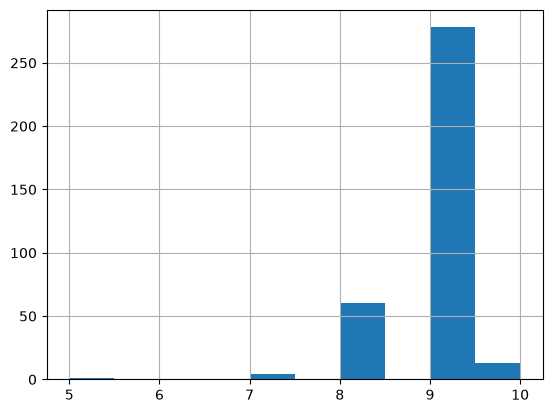

In [19]:
df['with_milk'].hist()

In [20]:
# for rows tested with milk, add a training sentence in 'desc_1' to reflect this score in natiral language

def milk_score_label(score):
    if score >= 9:
        return 'Tastes excellent with milk.'
    elif score >= 7:
        return 'Tastes good with milk.'
    else:
        return 'Tested with milk.'

milk_mask = df['with_milk'].notna()
milk_labels = df.loc[milk_mask, 'with_milk'].apply(milk_score_label)

df.loc[milk_mask, 'desc_1'] = df.loc[milk_mask, 'desc_1'] + ' ' + milk_labels

df = df.drop(columns=['with_milk'])

In [21]:
df.loc[milk_mask, 'desc_1'].head()[0]

'Evaluated as espresso. Sweet-toned, deeply rich, chocolaty. Vanilla paste, dark chocolate, narcissus, pink grapefruit zest, black cherry in aroma and cup. Plush, syrupy mouthfeel; resonant, flavor-saturated finish. In three parts milk, rich chocolate tones intensify, along with intimations of vanilla paste and black cherry in the short finish and floral-toned citrus zest in the long.  Tastes excellent with milk.'

In [22]:
# add roat level to 'desc-2_clean'
roast_mask = df['roast'].notna()
df.loc[roast_mask, 'desc_2_clean'] = df.loc[roast_mask, 'desc_2_clean'] + ' Roast level: ' + df.loc[roast_mask, 'roast'] + '.'

In [23]:
df['desc_2_clean'][0]

'An espresso blend comprised of coffees from Panama and Ethiopia. A.R.C., whose motto is “more than specialty,” rigorously controls three vital elements: sourcing of green coffee, roasting, and, in cafe environments, water quality for brewed coffee. Roast level: Medium-Light.'

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2282 entries, 0 to 2281
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   slug          2282 non-null   str    
 1   rating        2282 non-null   int64  
 2   roaster       2282 non-null   str    
 3   name          2282 non-null   str    
 4   location      2281 non-null   str    
 5   origin        2282 non-null   str    
 6   roast         2229 non-null   str    
 7   est_price     2277 non-null   str    
 8   review_date   2282 non-null   str    
 9   agtron        2282 non-null   str    
 10  aroma         2255 non-null   float64
 11  acid          1947 non-null   float64
 12  body          2279 non-null   float64
 13  flavor        2279 non-null   float64
 14  aftertaste    2279 non-null   float64
 15  desc_1        2282 non-null   str    
 16  desc_3        2280 non-null   str    
 17  desc_2_clean  2282 non-null   str    
dtypes: float64(5), int64(1), str(12)
memory

## Cleaning

In [25]:
## drop rows with null values for 'desc_3'

df = df.dropna(subset=['desc_3']).reset_index(drop=True)

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2280 entries, 0 to 2279
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   slug          2280 non-null   str    
 1   rating        2280 non-null   int64  
 2   roaster       2280 non-null   str    
 3   name          2280 non-null   str    
 4   location      2279 non-null   str    
 5   origin        2280 non-null   str    
 6   roast         2227 non-null   str    
 7   est_price     2275 non-null   str    
 8   review_date   2280 non-null   str    
 9   agtron        2280 non-null   str    
 10  aroma         2253 non-null   float64
 11  acid          1945 non-null   float64
 12  body          2277 non-null   float64
 13  flavor        2277 non-null   float64
 14  aftertaste    2277 non-null   float64
 15  desc_1        2280 non-null   str    
 16  desc_3        2280 non-null   str    
 17  desc_2_clean  2280 non-null   str    
dtypes: float64(5), int64(1), str(12)
memory

In [27]:
df[df['location'].isna()]['roaster']

15    A.R.C.
Name: roaster, dtype: str

In [28]:
df[df['roaster'] == 'A.R.C.']

,slug,rating,roaster,name,location,origin,roast,est_price,review_date,agtron,aroma,acid,body,flavor,aftertaste,desc_1,desc_3,desc_2_clean
0,https://www.coffeereview.com/review/sweety-esp...,95,A.R.C.,“Sweety” Espresso Blend,"Hong Kong, China",Panama; Ethiopia,Medium-Light,HKD $250/227 grams,November 2017,50/73,9.0,NaN,9.0,9.0,9.0,"Evaluated as espresso. Sweet-toned, deeply ric...",A radiant espresso blend that shines equally i...,An espresso blend comprised of coffees from Pa...
1,https://www.coffeereview.com/review/flora-blen...,94,A.R.C.,Flora Blend Espresso,"Hong Kong, China",Africa; Asia Pacific,Medium-Light,HKD $158/227 grams,November 2017,54/77,9.0,NaN,9.0,9.0,8.0,"Evaluated as espresso. Sweetly tart, floral-to...","A floral-driven straight shot, amplified with ...",An espresso blend comprised of coffees from Af...
14,https://www.coffeereview.com/review/flowery-es...,90,A.R.C.,“Flowery” Espresso Blend,"Hong Kong, China",Not disclosed,Medium-Light,HKD $128/227 grams,November 2017,55/74,8.0,NaN,8.0,9.0,7.0,Evaluated as espresso. Sweetly and richly tart...,"An accessible, sweetly tart espresso blend, ci...","A.R.C., whose motto is “more than specialty,” ..."
15,https://www.coffeereview.com/review/chocolate-...,89,A.R.C.,“Chocolate” Espresso Blend,NaN,Not disclosed,Medium,HKD $140/454 grams,November 2017,52/66,8.0,NaN,8.0,8.0,8.0,"Evaluated as espresso. Richly sweet-tart, wood...",Chocolaty but rather austere and bittersweet b...,"A.R.C., whose motto is “more than specialty,” ..."
16,https://www.coffeereview.com/review/nutty-espr...,88,A.R.C.,“Nutty” Espresso Blend,"Hong Kong, China",Not disclosed,Medium-Light,HKD $130/454 grams,November 2017,54/68,7.0,NaN,8.0,8.0,7.0,"Evaluated as espresso. Fir, almond, baker’s ch...","Nut and chocolate dominate in this crisp, bris...","A.R.C., whose motto is “more than specialty,” ..."
17,https://www.coffeereview.com/review/ethiopia-y...,92,A.R.C.,Ethiopia Yirgacheffe Washed G1,"Hong Kong, China","Yirgacheffe growing region, southern Ethiopia",Medium-Light,HKD $120/227 grams,November 2017,55/76,8.0,8.0,9.0,9.0,8.0,"Delicate, gently tart, spice-toned. Pomegranat...",A cup with a fine-tea-like appeal in its subtl...,"Produced in Yirgacheffe, a coffee region in so..."
18,https://www.coffeereview.com/review/blue-mount...,92,A.R.C.,“Blue Mountain Flavor” Blend,"Hong Kong, China",Not disclosed,Medium-Light,HKD $128/454 grams,November 2017,50/74,9.0,8.0,8.0,9.0,8.0,"Subtle, layered, sweetly tart. Blackcurrant, n...","A balanced, high-toned cup with attractive cho...","A.R.C., whose motto is “more than specialty,” ..."
19,https://www.coffeereview.com/review/house-blen...,91,A.R.C.,House Blend Espresso,"Hong Kong, China",Not disclosed,Medium-Light,HKD $128/227 grams,November 2017,56/78,8.0,NaN,9.0,8.0,7.0,"Evaluated as espresso. Crisply sweet, spice-to...","An espresso blend especially inviting in milk,...","A.R.C., whose motto is “more than specialty,” ..."
20,https://www.coffeereview.com/review/ethiopia-y...,91,A.R.C.,Ethiopia Yirgacheffe Natural G1,"Hong Kong, China","Yirgacheffe growing region, southern Ethiopia",Medium-Light,HKD $120/227 grams,November 2017,54/78,9.0,8.0,8.0,9.0,7.0,"Rich, sweet-toned, balanced. Nougat, pink pepp...",A crisply bittersweet cup that leads with spic...,Yirgacheffe is a coffee region in southern Eth...
21,https://www.coffeereview.com/review/fruity-esp...,95,A.R.C.,“Fruity” Espresso Blend,"Hong Kong, China",Ethiopia; Kenya; China,Medium-Light,HKD $200/227 grams,November 2017,54/78,9.0,NaN,9.0,9.0,9.0,"Evaluated as espresso. Subtle and enveloping, ...","Rich, sweet, elegant and cocoa-laden, this esp...",An espresso blend comprised of coffees from Et...


In [29]:
df[df['roaster'] == 'A.R.C.']['location']

0     Hong Kong, China
1     Hong Kong, China
14    Hong Kong, China
15                 NaN
16    Hong Kong, China
17    Hong Kong, China
18    Hong Kong, China
19    Hong Kong, China
20    Hong Kong, China
21    Hong Kong, China
96    Hong Kong, China
Name: location, dtype: str

In [30]:
missing_location = df[df['roaster'] == 'A.R.C.']['location'].unique()[0]

In [31]:
df.loc[df['location'].isna(), 'location'] = missing_location

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2280 entries, 0 to 2279
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   slug          2280 non-null   str    
 1   rating        2280 non-null   int64  
 2   roaster       2280 non-null   str    
 3   name          2280 non-null   str    
 4   location      2280 non-null   str    
 5   origin        2280 non-null   str    
 6   roast         2227 non-null   str    
 7   est_price     2275 non-null   str    
 8   review_date   2280 non-null   str    
 9   agtron        2280 non-null   str    
 10  aroma         2253 non-null   float64
 11  acid          1945 non-null   float64
 12  body          2277 non-null   float64
 13  flavor        2277 non-null   float64
 14  aftertaste    2277 non-null   float64
 15  desc_1        2280 non-null   str    
 16  desc_3        2280 non-null   str    
 17  desc_2_clean  2280 non-null   str    
dtypes: float64(5), int64(1), str(12)
memory

In [33]:
# fill other null values accordingly
df['roast'] = df['roast'].fillna('Unknown')
df['est_price'] = df['est_price'].fillna('Unknown')

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2280 entries, 0 to 2279
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   slug          2280 non-null   str    
 1   rating        2280 non-null   int64  
 2   roaster       2280 non-null   str    
 3   name          2280 non-null   str    
 4   location      2280 non-null   str    
 5   origin        2280 non-null   str    
 6   roast         2280 non-null   str    
 7   est_price     2280 non-null   str    
 8   review_date   2280 non-null   str    
 9   agtron        2280 non-null   str    
 10  aroma         2253 non-null   float64
 11  acid          1945 non-null   float64
 12  body          2277 non-null   float64
 13  flavor        2277 non-null   float64
 14  aftertaste    2277 non-null   float64
 15  desc_1        2280 non-null   str    
 16  desc_3        2280 non-null   str    
 17  desc_2_clean  2280 non-null   str    
dtypes: float64(5), int64(1), str(12)
memory

In [38]:
df['review_date']

0       November 2017
1       November 2017
2       November 2017
3       November 2017
4       November 2017
            ...      
2275    November 2022
2276    November 2022
2277    November 2022
2278    November 2022
2279    November 2022
Name: review_date, Length: 2280, dtype: str

In [39]:
# Convert review_date from "Month Year" (e.g., "November 2017") to datetime
df['review_date'] = pd.to_datetime(df['review_date'], format='%B %Y')

# Verify the conversion
print(df['review_date'].dtype)
print(df['review_date'].head())
print(df['review_date'].isna().sum())  # check nothing failed to parse

datetime64[us]
0   2017-11-01
1   2017-11-01
2   2017-11-01
3   2017-11-01
4   2017-11-01
Name: review_date, dtype: datetime64[us]
0


In [40]:
# Debug version - shows which rows fail instead of erroring out
test = pd.to_datetime(df['review_date'], format='%B %Y', errors='coerce')
print(df[test.isna()]['review_date'].unique())  # see the problem values

<DatetimeArray>
[]
Length: 0, dtype: datetime64[us]


In [41]:
save_dir = data_root / 'interim'
save_dir.mkdir(exist_ok=True, parents=True)
cleaned_fpath = save_dir / '01_coffee_review_clean.csv'
df.to_csv(cleaned_fpath, index=False)